In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import urllib
import warnings
from sqlalchemy import create_engine

warnings.filterwarnings('ignore')

# Database Connection
params = urllib.parse.quote_plus(
    'DRIVER={ODBC Driver 17 for SQL Server};'
    'SERVER=Wasif\\SQLEXPRESS;'
    'DATABASE=InventoryDB;'
    'Trusted_Connection=yes;'
    'TrustServerCertificate=yes;'
)
engine = create_engine(
    f'mssql+pyodbc:///?odbc_connect={params}',
    fast_executemany=True
)

# Load final table
df = pd.read_sql("SELECT * FROM vendor_sales_summary", engine)

print(f"✅ Data Loaded!")
print(f"Shape: {df.shape}")
print(df.head())

Matplotlib is building the font cache; this may take a moment.


✅ Data Loaded!
Shape: (8891, 18)
   VendorNumber                     VendorName  Brand  \
0             2  IRA GOLDMAN AND WILLIAMS, LLP  90085   
1            60        ADAMBA IMPORTS INTL INC    771   
2           105             ALTAMAR BRANDS LLC   2529   
3           105             ALTAMAR BRANDS LLC   8412   
4           200      AMERICAN SPIRITS EXCHANGE  20789   

                    Description  Volume  ActualPrice  PurchasePrice  \
0  Ch Lilian 09 Ladouys St Este   750.0        36.99          71.58   
1   Bak's Krupnik Honey Liqueur   750.0        14.99          45.76   
2                     Right Gin   750.0        29.99          46.50   
3     Tequila Ocho Plata Fresno   750.0        49.99        1964.05   
4           Zin-phomaniac Znfdl   750.0        14.99          58.38   

   TotalPurchaseQuantity  TotalPurchaseDollars  TotalSalesQuantity  \
0                      8                190.88                18.0   
1                     39                446.16           

In [3]:
# Summary Statistics
print("SUMMARY STATISTICS")
print("="*50)
print(df.describe().T)

SUMMARY STATISTICS
                        count          mean            std           min  \
VendorNumber           8891.0   9806.673940   17376.706801  2.000000e+00   
Brand                  8891.0  17830.273648   12873.710257  5.800000e+01   
Volume                 8891.0    861.476606     713.864979  5.000000e+01   
ActualPrice            8891.0     33.643442     115.258285  4.900000e-01   
PurchasePrice          8891.0   3109.444799    9025.596633  3.900000e-01   
TotalPurchaseQuantity  8891.0   3696.434709   12080.746858  1.000000e+00   
TotalPurchaseDollars   8891.0  35088.476624  134394.800505  7.100000e-01   
TotalSalesQuantity     8891.0   3673.551232   11932.086468  1.000000e+00   
TotalSalesDollars      8891.0  50479.062354  182952.968322  1.980000e+00   
TotalSalesPrice        8891.0  22299.078536   48577.700406  9.900000e-01   
TotalExciseTax         8891.0   2110.118732   12005.081649  1.000000e-01   
FreightCost            8891.0  61117.716620   62265.684160  9.000000e

## EDA — Distribution Analysis

### Key Observations:
- ActualPrice, TotalPurchaseDollars, TotalSalesDollars and GrossProfit are heavily right-skewed — outliers present due to premium brands
- ProfitMargin is normally distributed between 20-60% — healthy range
- StockTurnover is mostly low — most products sell slowly, few products sell very fast
- Outliers are NOT removed — they may represent premium high-value brands

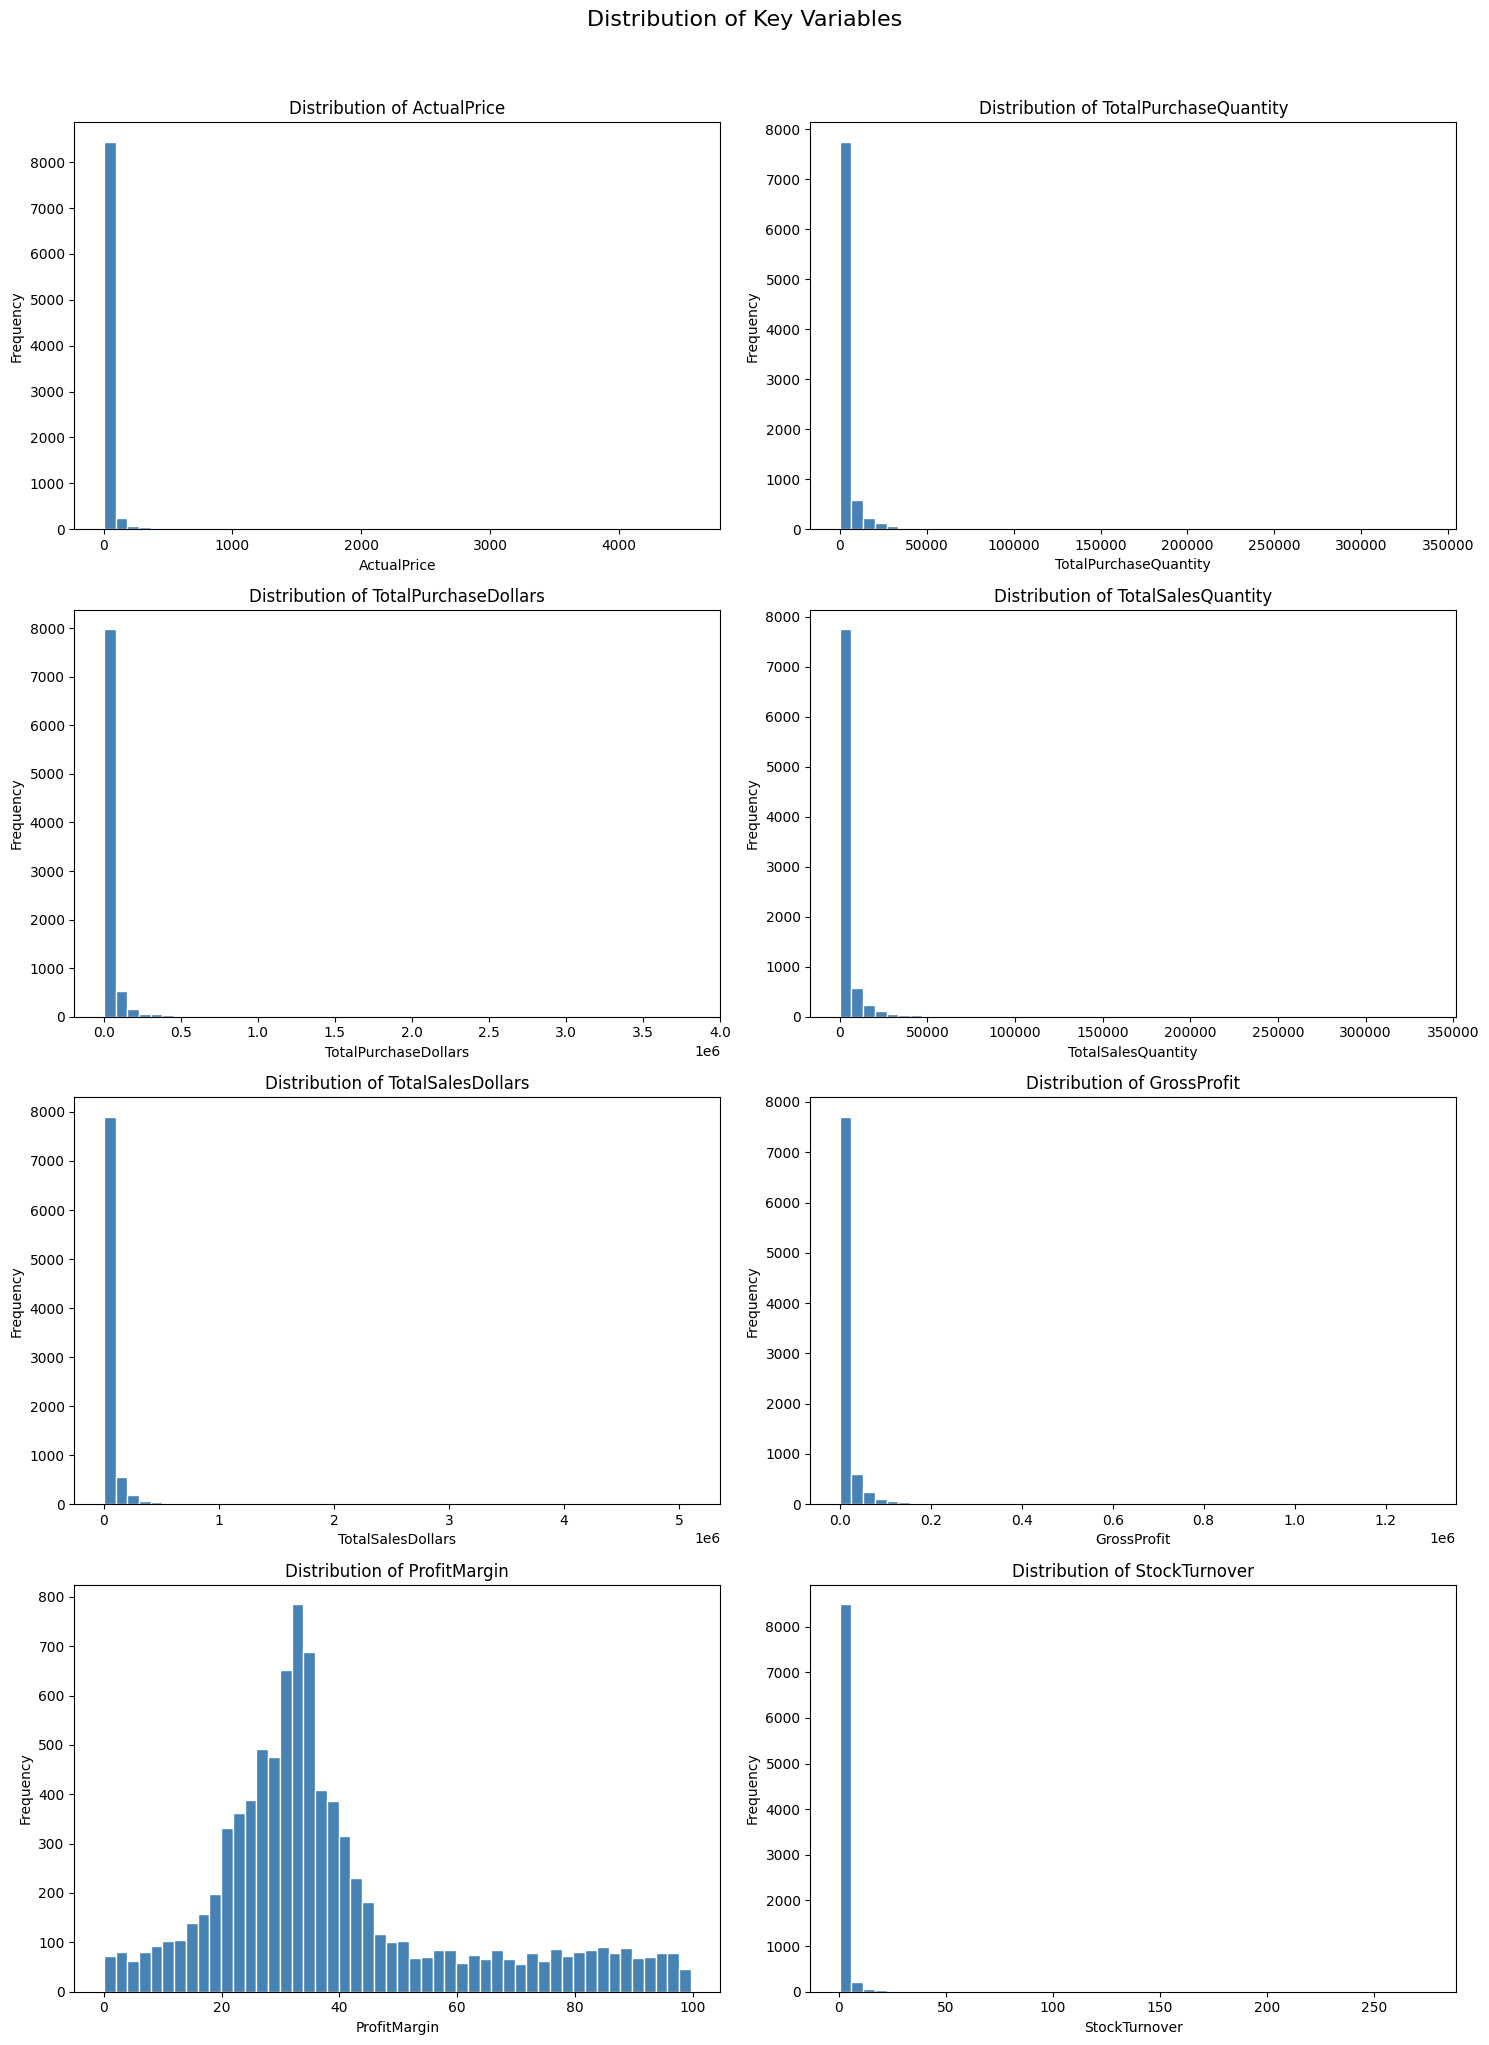

✅ Plot saved!


In [4]:
# Distribution Plots
numerical_cols = ['ActualPrice', 'TotalPurchaseQuantity', 
                  'TotalPurchaseDollars', 'TotalSalesQuantity',
                  'TotalSalesDollars', 'GrossProfit', 
                  'ProfitMargin', 'StockTurnover']

fig, axes = plt.subplots(4, 2, figsize=(15, 20))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    axes[i].hist(df[col], bins=50, color='steelblue', edgecolor='white')
    axes[i].set_title(f'Distribution of {col}', fontsize=12)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

plt.suptitle('Distribution of Key Variables', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('../reports/distribution_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot saved!")

## Correlation Analysis

### Key Insights:
- TotalPurchaseQuantity and TotalSalesQuantity are perfectly correlated (1.00) — efficient inventory management
- TotalSalesDollars and GrossProfit are strongly correlated (0.98) — more sales = more profit
- ProfitMargin and StockTurnover moderately correlated (0.41) — faster moving products tend to have better margins
- ActualPrice has no significant correlation with sales or profit — premium pricing does not hurt sales

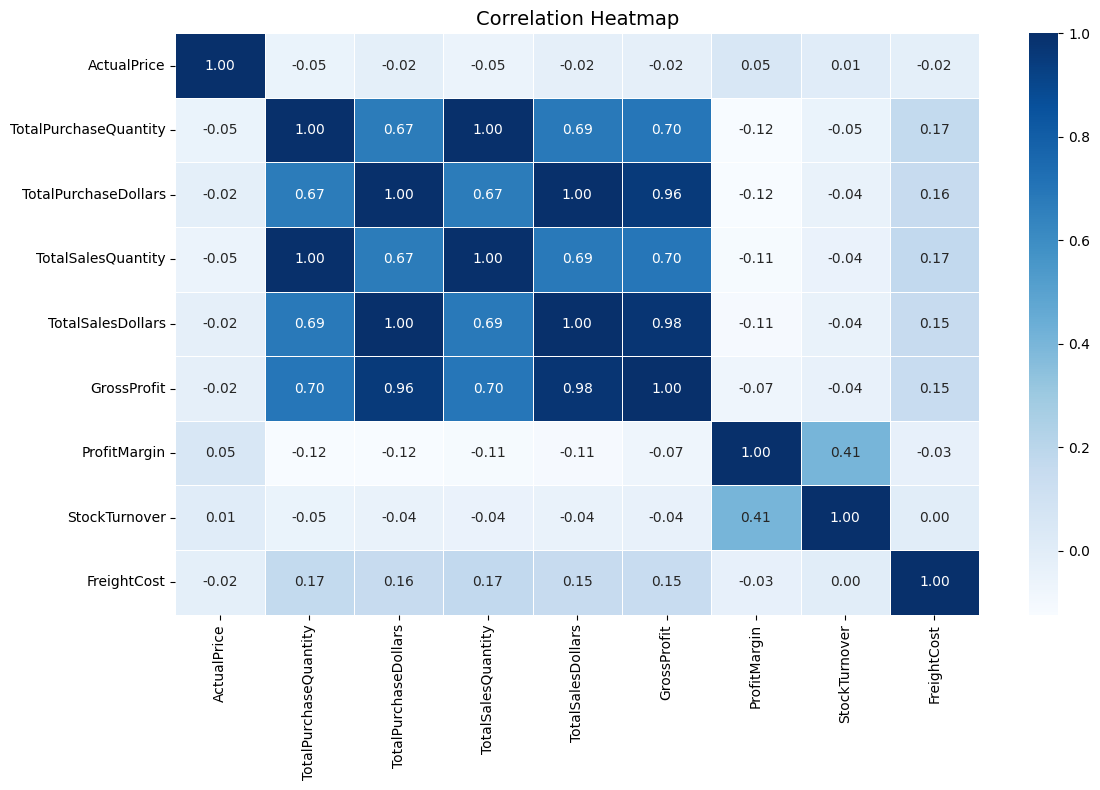

✅ Heatmap saved!


In [5]:
# Correlation Heatmap
numerical_cols = ['ActualPrice', 'TotalPurchaseQuantity',
                  'TotalPurchaseDollars', 'TotalSalesQuantity',
                  'TotalSalesDollars', 'GrossProfit',
                  'ProfitMargin', 'StockTurnover', 'FreightCost']

plt.figure(figsize=(12, 8))
corr = df[numerical_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', 
            cmap='Blues', linewidths=0.5)
plt.title('Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.savefig('../reports/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Heatmap saved!")

## RQ1: Brands Needing Promotional Adjustments

### Finding:
- 193 brands identified with low sales (< $577) but high profit margin (> 65%)
- These brands are profitable but not visible enough in the market
- Recommendation: Run sponsored ads, reduce pricing slightly or offer bundle deals to increase visibility and sales volume

In [6]:
# ── RQ1: Brands needing promotional/pricing adjustments ──
brand_performance = df.groupby('Description').agg(
    TotalSalesDollars=('TotalSalesDollars', 'sum'),
    ProfitMargin=('ProfitMargin', 'mean')
).reset_index()

# Set thresholds
low_sales_threshold  = brand_performance['TotalSalesDollars'].quantile(0.15)
high_margin_threshold = brand_performance['ProfitMargin'].quantile(0.85)

# Filter target brands
target_brands = brand_performance[
    (brand_performance['TotalSalesDollars'] < low_sales_threshold) &
    (brand_performance['ProfitMargin'] > high_margin_threshold)
]

print(f"Low Sales Threshold:   ${low_sales_threshold:,.2f}")
print(f"High Margin Threshold: {high_margin_threshold:.2f}%")
print(f"\nTarget Brands needing promotion: {len(target_brands)}")
print(target_brands.head(10))

Low Sales Threshold:   $577.48
High Margin Threshold: 65.04%

Target Brands needing promotion: 193
                      Description  TotalSalesDollars  ProfitMargin
6      12 Days of Pearls Gift Set             309.69     97.678323
45                 4 Orange Vodka             483.78     85.902683
57      A Bichot Clos Marechaudes             539.94     67.740860
59         A Bichot Merc Champs M             515.88     94.552997
96     Absolut Orient Apple Vodka             119.94     87.652159
129        Admiral Nelson Egg Nog             450.31     79.387533
183     Alma Negra Gran Almanegra             249.95     86.205241
202          Altadonna Vermentino             530.41     96.493279
229                Anarkos Puglia             299.76     66.212970
230  Anastasi Estates Messinia Rd             323.73     85.284033


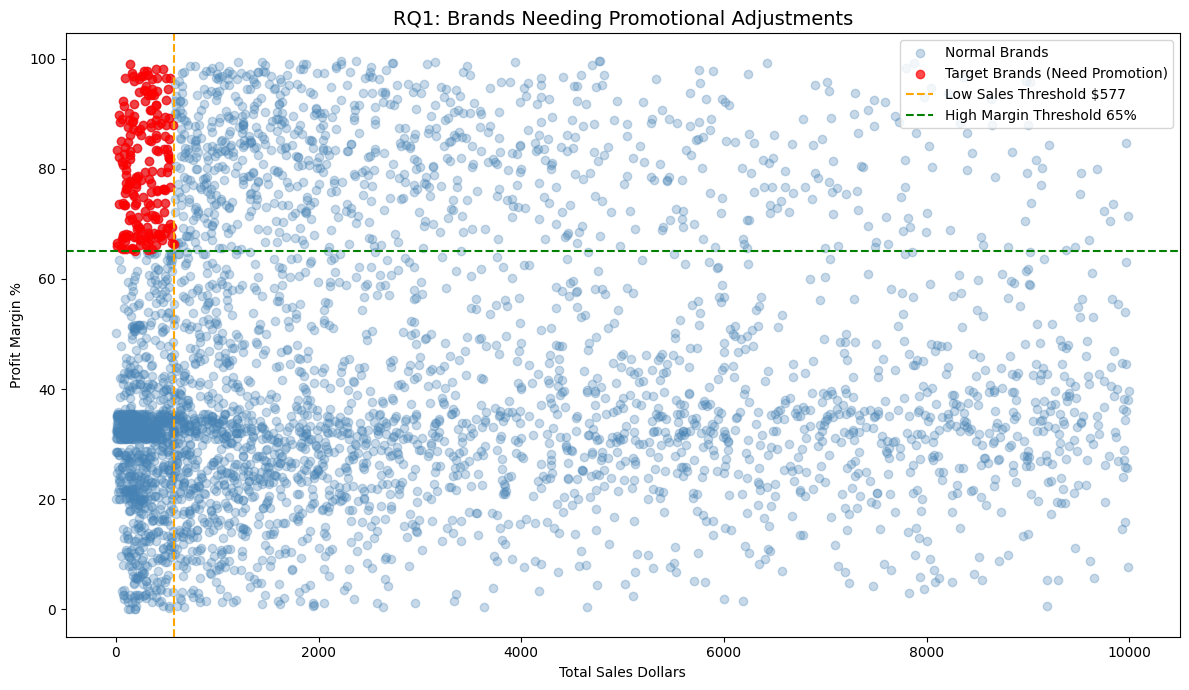

✅ Plot saved!


In [7]:
# Scatter plot — Target Brands
fig, ax = plt.subplots(figsize=(12, 7))

# Filter for better visualization
bp_filtered = brand_performance[
    brand_performance['TotalSalesDollars'] < 10000
]

# Normal brands
ax.scatter(
    bp_filtered['TotalSalesDollars'],
    bp_filtered['ProfitMargin'],
    color='steelblue', alpha=0.3, label='Normal Brands'
)

# Target brands
target_filtered = target_brands[
    target_brands['TotalSalesDollars'] < 10000
]
ax.scatter(
    target_filtered['TotalSalesDollars'],
    target_filtered['ProfitMargin'],
    color='red', alpha=0.7, label='Target Brands (Need Promotion)'
)

# Threshold lines
ax.axvline(x=low_sales_threshold, color='orange', 
           linestyle='--', label=f'Low Sales Threshold ${low_sales_threshold:,.0f}')
ax.axhline(y=high_margin_threshold, color='green', 
           linestyle='--', label=f'High Margin Threshold {high_margin_threshold:.0f}%')

ax.set_xlabel('Total Sales Dollars')
ax.set_ylabel('Profit Margin %')
ax.set_title('RQ1: Brands Needing Promotional Adjustments', fontsize=14)
ax.legend()
plt.tight_layout()
plt.savefig('../reports/rq1_target_brands.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot saved!")

## RQ2: Top Vendors and Brands by Sales

### Finding:
- DIAGEO NORTH AMERICA INC is the top vendor with $67.99M in sales
- Top 3 vendors (Diageo, Martignetti, Pernod Ricard) contribute over $139M combined
- Jack Daniels No 7 Black is the top brand with $7.96M
- Top brands are all well known spirits — Vodka, Whiskey and Rum dominate
### Recommendation:
- Strengthen relationships with top 3 vendors
- Increase stock of top performing brands especially Jack Daniels and Tito's Vodka

In [8]:
# RQ2 — Top 10 Vendors by Sales
top_vendors = df.groupby('VendorName')['TotalSalesDollars']\
                .sum().sort_values(ascending=False).head(10)

# Top 10 Brands by Sales
top_brands = df.groupby('Description')['TotalSalesDollars']\
               .sum().sort_values(ascending=False).head(10)

# Format to Millions
def format_dollars(val):
    if val >= 1_000_000:
        return f'${val/1_000_000:.2f}M'
    elif val >= 1_000:
        return f'${val/1_000:.1f}K'
    return f'${val:.0f}'

print("TOP 10 VENDORS BY SALES:")
for v, s in top_vendors.items():
    print(f"  {v:<40} {format_dollars(s)}")

print("\nTOP 10 BRANDS BY SALES:")
for b, s in top_brands.items():
    print(f"  {b:<40} {format_dollars(s)}")

TOP 10 VENDORS BY SALES:
  DIAGEO NORTH AMERICA INC                 $67.99M
  MARTIGNETTI COMPANIES                    $39.33M
  PERNOD RICARD USA                        $32.06M
  JIM BEAM BRANDS COMPANY                  $31.42M
  BACARDI USA INC                          $24.85M
  CONSTELLATION BRANDS INC                 $24.22M
  E & J GALLO WINERY                       $18.40M
  BROWN-FORMAN CORP                        $18.25M
  ULTRA BEVERAGE COMPANY LLP               $16.50M
  M S WALKER INC                           $14.71M

TOP 10 BRANDS BY SALES:
  Jack Daniels No 7 Black                  $7.96M
  Tito's Handmade Vodka                    $7.40M
  Grey Goose Vodka                         $7.21M
  Capt Morgan Spiced Rum                   $6.36M
  Absolut 80 Proof                         $6.24M
  Jameson Irish Whiskey                    $5.72M
  Ketel One Vodka                          $5.07M
  Baileys Irish Cream                      $4.15M
  Kahlua                                

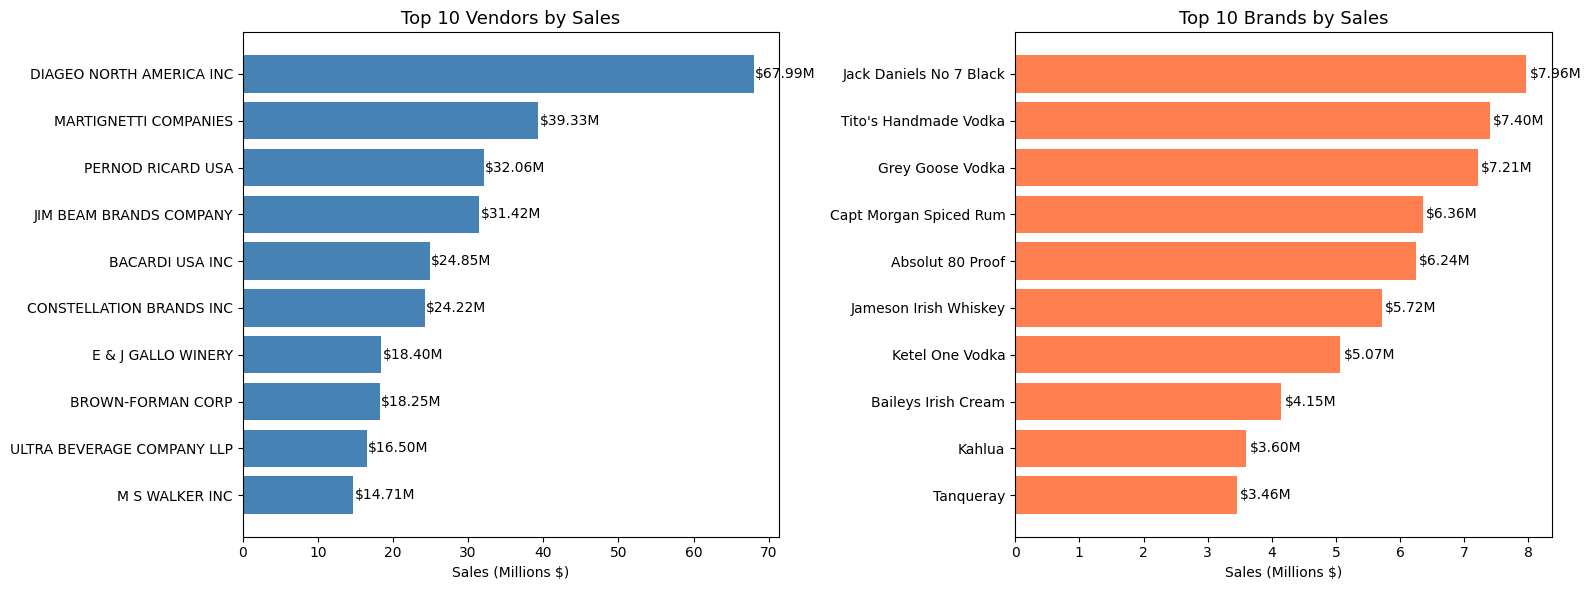

✅ Plot saved!


In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Top Vendors
ax1.barh(top_vendors.index[::-1], 
         top_vendors.values[::-1]/1_000_000,
         color='steelblue')
ax1.set_xlabel('Sales (Millions $)')
ax1.set_title('Top 10 Vendors by Sales', fontsize=13)
for i, v in enumerate(top_vendors.values[::-1]):
    ax1.text(v/1_000_000 + 0.2, i, format_dollars(v), va='center')

# Top Brands
ax2.barh(top_brands.index[::-1], 
         top_brands.values[::-1]/1_000_000,
         color='coral')
ax2.set_xlabel('Sales (Millions $)')
ax2.set_title('Top 10 Brands by Sales', fontsize=13)
for i, v in enumerate(top_brands.values[::-1]):
    ax2.text(v/1_000_000 + 0.05, i, format_dollars(v), va='center')

plt.tight_layout()
plt.savefig('../reports/rq2_top_vendors_brands.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot saved!")

In [10]:
# RQ3 — Vendor Purchase Contribution
vendor_purchase = df.groupby('VendorName')['TotalPurchaseDollars']\
                    .sum().sort_values(ascending=False)

total_purchases = vendor_purchase.sum()

vendor_purchase_pct = (vendor_purchase / total_purchases * 100)\
                       .round(2).head(10)

print("TOP 10 VENDORS BY PURCHASE CONTRIBUTION:")
for v, p in vendor_purchase_pct.items():
    print(f"  {v:<40} {p:.2f}%")

top10_contribution = vendor_purchase_pct.sum()
print(f"\nTop 10 vendors contribute: {top10_contribution:.2f}% of total purchases")
print(f"Remaining vendors contribute: {100-top10_contribution:.2f}%")

TOP 10 VENDORS BY PURCHASE CONTRIBUTION:
  DIAGEO NORTH AMERICA INC                 16.06%
  MARTIGNETTI COMPANIES                    8.17%
  PERNOD RICARD USA                        7.65%
  JIM BEAM BRANDS COMPANY                  7.53%
  BACARDI USA INC                          5.59%
  CONSTELLATION BRANDS INC                 4.90%
  BROWN-FORMAN CORP                        4.24%
  E & J GALLO WINERY                       3.87%
  ULTRA BEVERAGE COMPANY LLP               3.58%
  M S WALKER INC                           3.13%

Top 10 vendors contribute: 64.72% of total purchases
Remaining vendors contribute: 35.28%


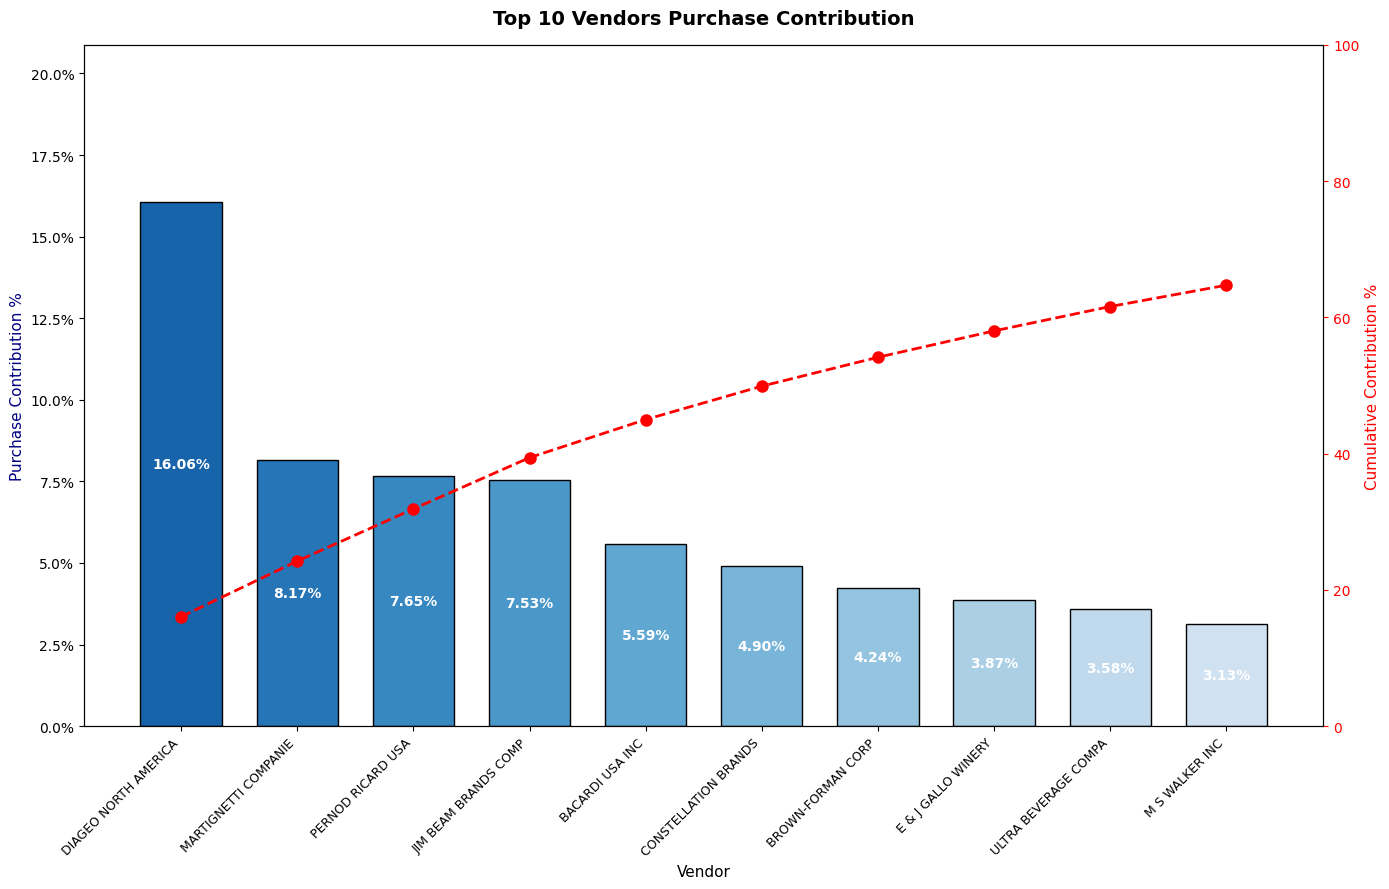

✅ Plot saved!


In [23]:
import matplotlib.ticker as mtick
import matplotlib.cm as cm

fig, ax1 = plt.subplots(figsize=(14, 9))

# Gradient colors
colors = plt.cm.Blues_r(np.linspace(0.2, 0.8, 10))

bars = ax1.bar(
    vendor_purchase_pct.index,
    vendor_purchase_pct.values,
    color=colors,
    edgecolor='black',
    width=0.7
)

ax1.set_title('Top 10 Vendors Purchase Contribution', 
              fontsize=14, fontweight='bold', pad=15)
ax1.set_xlabel('Vendor', fontsize=11)
ax1.set_ylabel('Purchase Contribution %', fontsize=11, color='navy')
ax1.set_ylim(0, vendor_purchase_pct.max() * 1.3)
ax1.yaxis.set_major_formatter(mtick.PercentFormatter())
ax1.set_xticks(range(len(vendor_purchase_pct.index)))
ax1.set_xticklabels(
    [name[:20] for name in vendor_purchase_pct.index],
    rotation=45, ha='right', fontsize=9
)

# Percentage labels INSIDE bars
for bar, pct in zip(bars, vendor_purchase_pct.values):
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() / 2,
        f'{pct:.2f}%',
        ha='center', va='center',
        fontsize=10, fontweight='bold',
        color='white'
    )

# Cumulative line on secondary axis
ax2 = ax1.twinx()
cumulative = vendor_purchase_pct.cumsum().values
ax2.plot(range(10), cumulative,
         color='red', marker='o',
         linewidth=2, linestyle='--',
         markersize=8)
ax2.set_ylabel('Cumulative Contribution %', 
               fontsize=11, color='red')
ax2.tick_params(axis='y', colors='red')
ax2.set_ylim(0, 100)

plt.tight_layout()
plt.savefig('../reports/rq3_purchase_contribution.png', 
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot saved!")

In [13]:
# RQ4 — Bulk Purchasing Impact on Unit Cost
df['UnitPurchasePrice'] = (
    df['TotalPurchaseDollars'] / df['TotalPurchaseQuantity']
)

# Create order size buckets
df['OrderSize'] = pd.qcut(
    df['TotalPurchaseQuantity'],
    q=3,
    labels=['Small', 'Medium', 'Large']
)

# Mean unit price per order size
bulk_analysis = df.groupby('OrderSize', observed=True)['UnitPurchasePrice']\
                  .mean().round(2)

print("BULK PURCHASING ANALYSIS:")
print("="*40)
for size, price in bulk_analysis.items():
    print(f"  {size:<10} Avg Unit Price: ${price:.2f}")

# Price reduction
small_price = bulk_analysis['Small']
large_price = bulk_analysis['Large']
reduction = ((small_price - large_price) / small_price * 100)
print(f"\nPrice reduction from Small to Large: {reduction:.1f}%")

BULK PURCHASING ANALYSIS:
  Small      Avg Unit Price: $41.38
  Medium     Avg Unit Price: $15.42
  Large      Avg Unit Price: $10.74

Price reduction from Small to Large: 74.0%


## RQ4: Impact of Bulk Purchasing on Unit Cost

### Finding:
- Small orders: $41.38 per unit
- Medium orders: $15.42 per unit  
- Large orders: $10.74 per unit
- 74% price reduction from small to large orders
### Recommendation:
- Encourage vendors to purchase in bulk through volume discounts
- Bulk pricing strategy is already working — reinforce it further

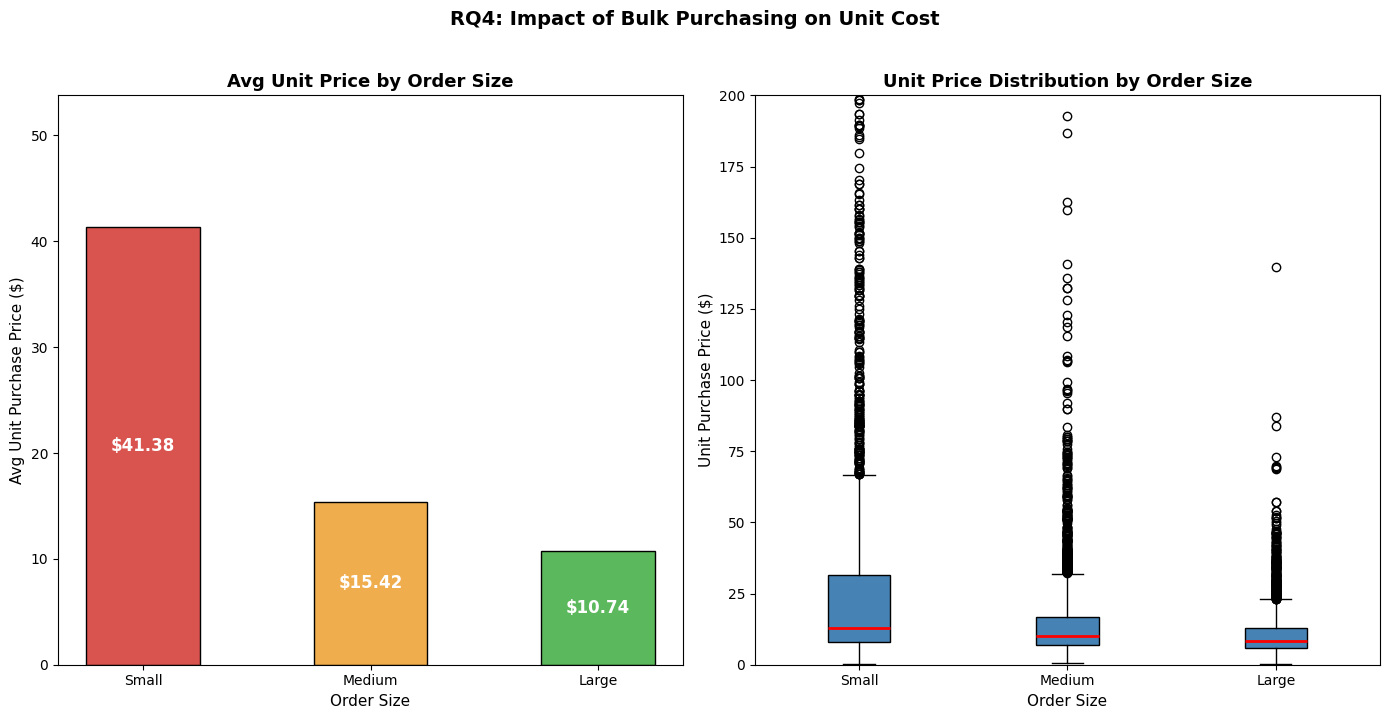

✅ Plot saved!


In [24]:
# RQ4 Visualization — Bulk Purchasing Impact
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))

# ── Left: Bar chart with prices ──
order_sizes = bulk_analysis.index.tolist()
prices = bulk_analysis.values
bar_colors = ['#d9534f', '#f0ad4e', '#5cb85c']

bars = ax1.bar(order_sizes, prices, color=bar_colors, 
               edgecolor='black', width=0.5)

ax1.set_title('Avg Unit Price by Order Size', 
              fontsize=13, fontweight='bold')
ax1.set_xlabel('Order Size', fontsize=11)
ax1.set_ylabel('Avg Unit Purchase Price ($)', fontsize=11)
ax1.set_ylim(0, prices.max() * 1.3)

# Price labels inside bars
for bar, price in zip(bars, prices):
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() / 2,
        f'${price:.2f}',
        ha='center', va='center',
        fontsize=12, fontweight='bold',
        color='white'
    )

# ── Right: Box plot ──
small  = df[df['OrderSize'] == 'Small']['UnitPurchasePrice']
medium = df[df['OrderSize'] == 'Medium']['UnitPurchasePrice']
large  = df[df['OrderSize'] == 'Large']['UnitPurchasePrice']

ax2.boxplot([small, medium, large],
            labels=['Small', 'Medium', 'Large'],
            patch_artist=True,
            boxprops=dict(facecolor='steelblue', color='black'),
            medianprops=dict(color='red', linewidth=2))

ax2.set_title('Unit Price Distribution by Order Size',
              fontsize=13, fontweight='bold')
ax2.set_xlabel('Order Size', fontsize=11)
ax2.set_ylabel('Unit Purchase Price ($)', fontsize=11)
ax2.set_ylim(0, 200)

plt.suptitle('RQ4: Impact of Bulk Purchasing on Unit Cost',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../reports/rq4_bulk_purchasing.png', 
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot saved!")

In [25]:
# RQ5 — Low Inventory Turnover Vendors
low_turnover = df[df['StockTurnover'] < 1]\
    .groupby('VendorName')['StockTurnover']\
    .mean().round(3)\
    .sort_values(ascending=True)\
    .head(10)

print("TOP 10 VENDORS WITH LOWEST INVENTORY TURNOVER:")
print("="*50)
for v, t in low_turnover.items():
    print(f"  {v:<40} {t:.3f}")

TOP 10 VENDORS WITH LOWEST INVENTORY TURNOVER:
  ALISA CARR BEVERAGES                     0.615
  HIGHLAND WINE MERCHANTS LLC              0.708
  PARK STREET IMPORTS LLC                  0.751
  Circa Wines                              0.756
  Dunn Wine Brokers                        0.766
  CENTEUR IMPORTS LLC                      0.774
  SMOKY QUARTZ DISTILLERY LLC              0.784
  TAMWORTH DISTILLING                      0.797
  THE IMPORTED GRAPE LLC                   0.808
  WALPOLE MTN VIEW WINERY                  0.821


## RQ5: Vendors with Low Inventory Turnover

### Finding:
- 10 vendors identified with stock turnover below 1.0
- ALISA CARR BEVERAGES has the lowest turnover at 0.615
- All vendors are significantly below the target of 1.0
### Recommendation:
- Advise these vendors to reduce purchase quantities
- Launch clearance sales for slow moving products
- Revise storage and ordering strategies

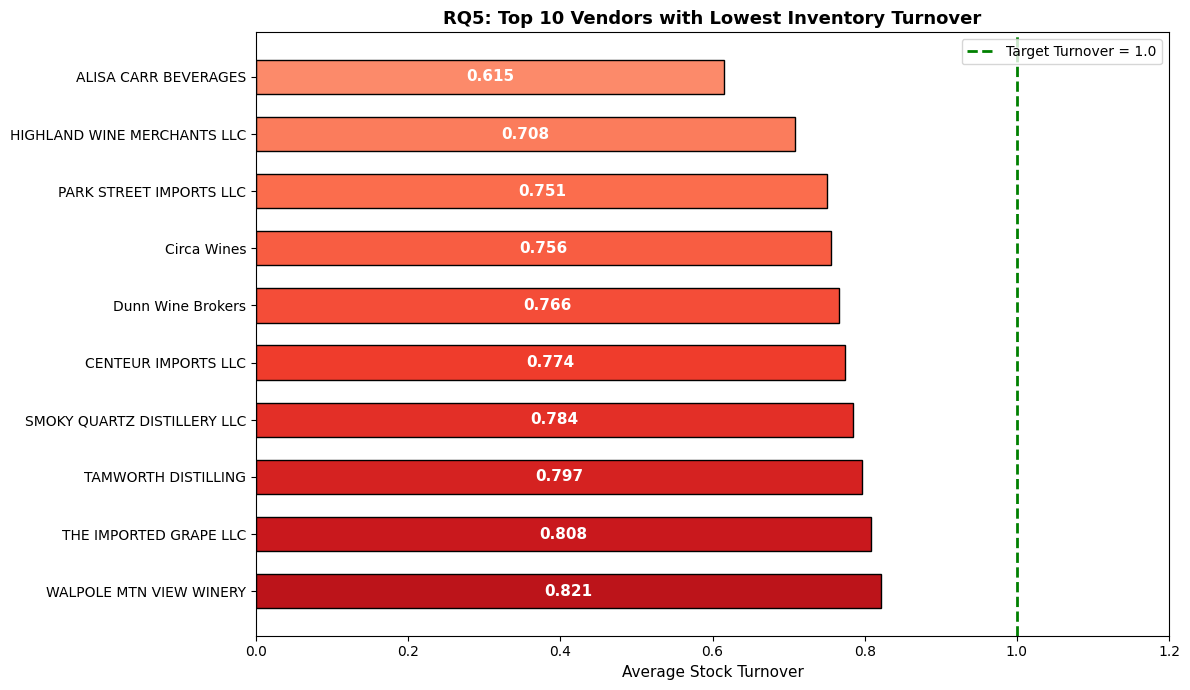

✅ Plot saved!


In [26]:
# RQ5 Visualization — Low Turnover Vendors
fig, ax = plt.subplots(figsize=(12, 7))

colors = plt.cm.Reds(np.linspace(0.4, 0.8, 10))

bars = ax.barh(
    low_turnover.index[::-1],
    low_turnover.values[::-1],
    color=colors[::-1],
    edgecolor='black',
    height=0.6
)

# Value labels inside bars
for bar, val in zip(bars, low_turnover.values[::-1]):
    ax.text(
        bar.get_width() / 2,
        bar.get_y() + bar.get_height() / 2,
        f'{val:.3f}',
        ha='center', va='center',
        fontsize=11, fontweight='bold',
        color='white'
    )

# Reference line at 1.0
ax.axvline(x=1.0, color='green', linestyle='--', 
           linewidth=2, label='Target Turnover = 1.0')

ax.set_xlabel('Average Stock Turnover', fontsize=11)
ax.set_title('RQ5: Top 10 Vendors with Lowest Inventory Turnover',
             fontsize=13, fontweight='bold')
ax.set_xlim(0, 1.2)
ax.legend()
plt.tight_layout()
plt.savefig('../reports/rq5_low_turnover.png', 
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot saved!")

In [27]:
# RQ6 — Unsold Inventory Capital
df['UnsoldInventoryValue'] = (
    (df['TotalPurchaseQuantity'] - df['TotalSalesQuantity']) * 
    df['ActualPrice']
)

# Total capital locked
total_unsold = df['UnsoldInventoryValue'].sum()
print(f"Total Capital Locked in Unsold Inventory: {format_dollars(total_unsold)}")

# Top 10 vendors contributing to unsold inventory
unsold_by_vendor = df.groupby('VendorName')['UnsoldInventoryValue']\
                     .sum().sort_values(ascending=False).head(10)

print("\nTOP 10 VENDORS WITH MOST UNSOLD INVENTORY:")
print("="*55)
for v, val in unsold_by_vendor.items():
    print(f"  {v:<40} {format_dollars(val)}")

Total Capital Locked in Unsold Inventory: $3.66M

TOP 10 VENDORS WITH MOST UNSOLD INVENTORY:
  DIAGEO NORTH AMERICA INC                 $984.2K
  JIM BEAM BRANDS COMPANY                  $761.2K
  PERNOD RICARD USA                        $647.4K
  WILLIAM GRANT & SONS INC                 $538.7K
  E & J GALLO WINERY                       $369.7K
  SAZERAC CO INC                           $273.4K
  BROWN-FORMAN CORP                        $247.1K
  CONSTELLATION BRANDS INC                 $227.4K
  MOET HENNESSY USA INC                    $197.6K
  MAJESTIC FINE WINES                      $180.7K


## RQ6: Capital Locked in Unsold Inventory

### Finding:
- Total $3.66 Million capital is locked in unsold inventory
- DIAGEO has the highest unsold inventory at $984K
- Top 3 vendors (DIAGEO, JIM BEAM, PERNOD RICARD) account for $2.39M of unsold stock
### Recommendation:
- Launch clearance sales for slow moving products
- Reduce future purchase quantities for these vendors
- Negotiate return policies with top vendors

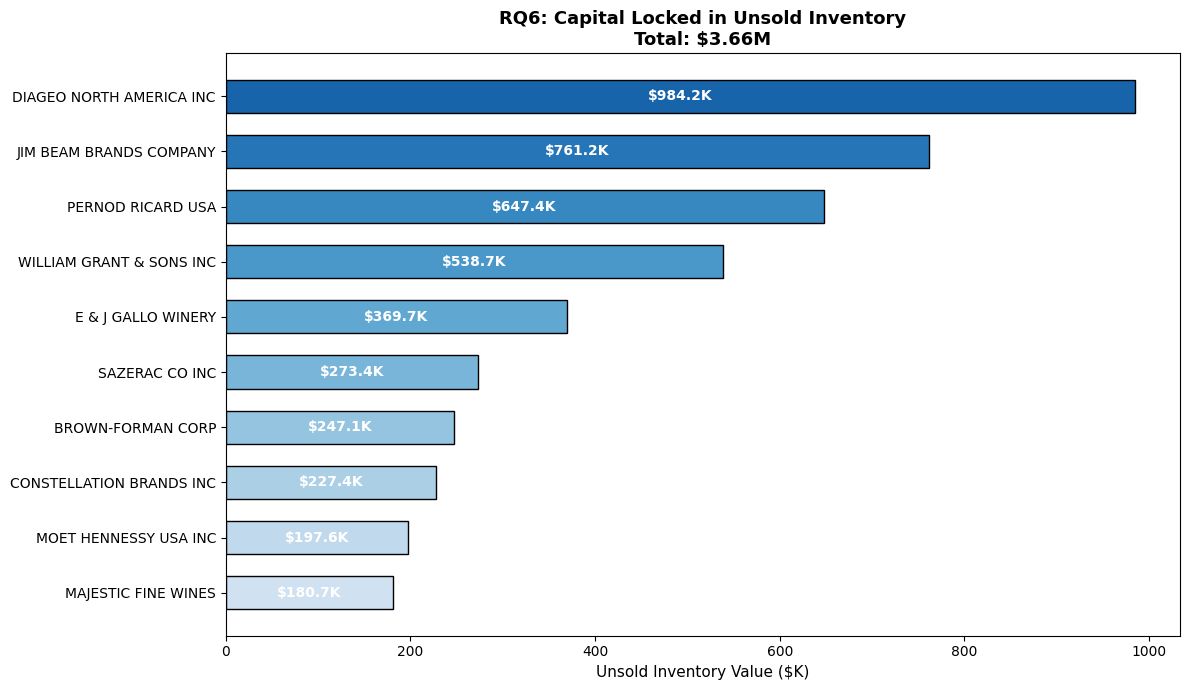

✅ Plot saved!


In [28]:
# RQ6 Visualization
fig, ax = plt.subplots(figsize=(12, 7))

colors = plt.cm.Blues_r(np.linspace(0.2, 0.8, 10))

bars = ax.barh(
    unsold_by_vendor.index[::-1],
    unsold_by_vendor.values[::-1] / 1000,
    color=colors[::-1],
    edgecolor='black',
    height=0.6
)

# Value labels inside bars
for bar, val in zip(bars, unsold_by_vendor.values[::-1]):
    ax.text(
        bar.get_width() / 2,
        bar.get_y() + bar.get_height() / 2,
        format_dollars(val),
        ha='center', va='center',
        fontsize=10, fontweight='bold',
        color='white'
    )

ax.set_xlabel('Unsold Inventory Value ($K)', fontsize=11)
ax.set_title(
    f'RQ6: Capital Locked in Unsold Inventory\nTotal: {format_dollars(total_unsold)}',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig('../reports/rq6_unsold_inventory.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot saved!")

In [29]:
from scipy import stats

# Define top and low performing vendors
high_threshold = df['TotalSalesDollars'].quantile(0.75)
low_threshold  = df['TotalSalesDollars'].quantile(0.25)

top_vendors_margin = df[df['TotalSalesDollars'] > high_threshold]['ProfitMargin']
low_vendors_margin = df[df['TotalSalesDollars'] < low_threshold]['ProfitMargin']

# Confidence Interval Function
def confidence_interval(data, confidence=0.95):
    mean   = data.mean()
    se     = stats.sem(data)
    t_crit = stats.t.ppf((1 + confidence) / 2, df=len(data) - 1)
    margin = t_crit * se
    return mean, mean - margin, mean + margin

top_mean, top_lower, top_upper = confidence_interval(top_vendors_margin)
low_mean, low_lower, low_upper = confidence_interval(low_vendors_margin)

print("CONFIDENCE INTERVALS FOR PROFIT MARGIN (95%)")
print("="*50)
print(f"Top Performing Vendors:  {top_lower:.2f}% to {top_upper:.2f}%  (Mean: {top_mean:.2f}%)")
print(f"Low Performing Vendors:  {low_lower:.2f}% to {low_upper:.2f}%  (Mean: {low_mean:.2f}%)")

CONFIDENCE INTERVALS FOR PROFIT MARGIN (95%)
Top Performing Vendors:  30.89% to 31.74%  (Mean: 31.31%)
Low Performing Vendors:  40.65% to 42.74%  (Mean: 41.70%)


## RQ7 & RQ8: Confidence Intervals & Hypothesis Testing

### RQ7 Finding:
- Top Performing Vendors profit margin: 30.89% to 31.74%
- Low Performing Vendors profit margin: 40.65% to 42.74%
- Low performing vendors have HIGHER margins — they sell premium products in low volumes

### RQ8 Finding:
- T-Statistic: -17.98  |  P-Value: 0.000000
- REJECT H0 — Significant difference confirmed statistically
- The difference in profit margins is NOT by chance

### Recommendation:
- Top vendors should explore selective price adjustments to improve margins
- Low vendors should focus on increasing sales volume through better marketing

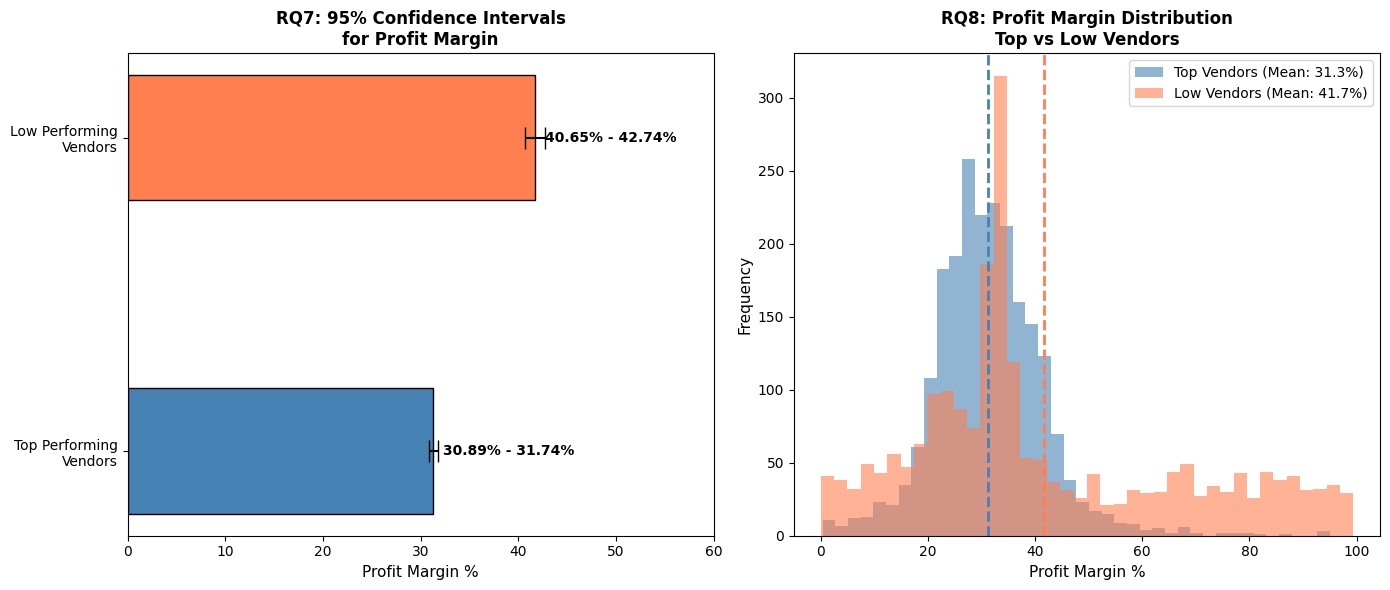


HYPOTHESIS TESTING RESULTS
H0: No significant difference in profit margins
H1: Significant difference exists

T-Statistic: -17.9851
P-Value:     0.000000

✅ REJECT H0 — Significant difference exists!


In [ ]:
# RQ7 Visualization + RQ8 Hypothesis Testing
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# ── Left: Confidence Interval Plot ──
categories = ['Top Performing\nVendors', 'Low Performing\nVendors']
means      = [top_mean, low_mean]
lowers     = [top_mean - top_lower, low_mean - low_lower]
uppers     = [top_upper - top_mean, low_upper - low_mean]

ax1.barh(categories, means, 
         xerr=[lowers, uppers],
         color=['steelblue', 'coral'],
         edgecolor='black', height=0.4,
         capsize=8)

for i, (mean, lower, upper) in enumerate(
        zip(means, [top_lower, low_lower], [top_upper, low_upper])):
    ax1.text(mean + 1, i, 
             f'{lower:.2f}% - {upper:.2f}%',
             va='center', fontsize=10, fontweight='bold')

ax1.set_xlabel('Profit Margin %', fontsize=11)
ax1.set_title('RQ7: 95% Confidence Intervals\nfor Profit Margin', 
              fontsize=12, fontweight='bold')
ax1.set_xlim(0, 60)

# ── Right: Distribution Plot ──
ax2.hist(top_vendors_margin, bins=40, 
         alpha=0.6, color='steelblue', 
         label=f'Top Vendors (Mean: {top_mean:.1f}%)')
ax2.hist(low_vendors_margin, bins=40, 
         alpha=0.6, color='coral',
         label=f'Low Vendors (Mean: {low_mean:.1f}%)')
ax2.axvline(top_mean, color='steelblue', 
            linestyle='--', linewidth=2)
ax2.axvline(low_mean, color='coral', 
            linestyle='--', linewidth=2)
ax2.set_xlabel('Profit Margin %', fontsize=11)
ax2.set_ylabel('Frequency', fontsize=11)
ax2.set_title('RQ8: Profit Margin Distribution\nTop vs Low Vendors',
              fontsize=12, fontweight='bold')
ax2.legend()

plt.tight_layout()
plt.savefig('../reports/rq7_rq8_confidence_hypothesis.png',
            dpi=150, bbox_inches='tight')
plt.show()

# ── RQ8: Hypothesis Testing ──
t_stat, p_value = stats.ttest_ind(top_vendors_margin, 
                                   low_vendors_margin)
print("\nHYPOTHESIS TESTING RESULTS")
print("="*45)
print(f"H0: No significant difference in profit margins")
print(f"H1: Significant difference exists")
print(f"\nT-Statistic: {t_stat:.4f}")
print(f"P-Value:     {p_value:.6f}")
if p_value < 0.05:
    print("\n✅ REJECT H0 — Significant difference exists!")
else:
    print("\n❌ FAIL TO REJECT H0")

In [31]:
# Export final table for Power BI
df.to_csv('../data/vendor_sales_summary.csv', index=False)
print("✅ File saved for Power BI!")
print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")

✅ File saved for Power BI!
Shape: (8891, 21)
Columns: ['VendorNumber', 'VendorName', 'Brand', 'Description', 'Volume', 'ActualPrice', 'PurchasePrice', 'TotalPurchaseQuantity', 'TotalPurchaseDollars', 'TotalSalesQuantity', 'TotalSalesDollars', 'TotalSalesPrice', 'TotalExciseTax', 'FreightCost', 'GrossProfit', 'ProfitMargin', 'StockTurnover', 'SalesToPurchaseRatio', 'UnitPurchasePrice', 'OrderSize', 'UnsoldInventoryValue']


In [1]:
import logging
import os

os.makedirs('../logs', exist_ok=True)

# Create logger for this notebook
logger = logging.getLogger('vendor_performance_analysis')
logger.setLevel(logging.DEBUG)

# Avoid duplicate handlers if cell is re-run
if not logger.handlers:
    handler = logging.FileHandler('../logs/vendor_performance_analysis.log', mode='a')
    handler.setFormatter(logging.Formatter('%(asctime)s - %(levelname)s - %(message)s'))
    logger.addHandler(handler)

logger.info('=== Vendor Performance Analysis Started ===')

# Data Loading
logger.info('Step 1: Connected to InventoryDB using ODBC Driver 17 for SQL Server')
logger.info('Step 2: Loaded vendor_sales_summary table — 8,891 rows, 18 columns')

# EDA
logger.info('Step 3: Summary Statistics — identified negative profit, inf margins, high turnover outliers')
logger.info('Step 4: Distribution plots generated for 8 key variables — all right-skewed except ProfitMargin')
logger.info('Step 5: Outliers NOT removed — may represent premium high-value brands')
logger.info('Step 6: Correlation Heatmap — PurchaseQty vs SalesQty = 1.00, SalesDollars vs GrossProfit = 0.98')

# RQ1
logger.info('Step 7: RQ1 — 193 target brands identified: low sales (< $577) and high margin (> 65%)')
logger.info('Step 8: RQ1 — Scatter plot saved to ../reports/rq1_target_brands.png')

# RQ2
logger.info('Step 9: RQ2 — Top vendor: DIAGEO NORTH AMERICA INC — $67.99M in sales')
logger.info('Step 10: RQ2 — Top brand: Jack Daniels No 7 Black — $7.96M in sales')
logger.info('Step 11: RQ2 — Bar charts saved to ../reports/rq2_top_vendors_brands.png')

# RQ3
logger.info('Step 12: RQ3 — Top 10 vendors contribute 64.72% of total purchases')
logger.info('Step 13: RQ3 — DIAGEO alone accounts for 16.06% — high concentration risk')
logger.info('Step 14: RQ3 — Pareto chart saved to ../reports/rq3_purchase_contribution.png')

# RQ4
logger.info('Step 15: RQ4 — UnitPurchasePrice = TotalPurchaseDollars / TotalPurchaseQuantity')
logger.info('Step 16: RQ4 — Orders bucketed into Small / Medium / Large using pd.qcut')
logger.info('Step 17: RQ4 — Small: $41.38 | Medium: $15.42 | Large: $10.74 per unit')
logger.info('Step 18: RQ4 — 74% cost reduction from small to large orders confirmed')
logger.info('Step 19: RQ4 — Bar + Box plot saved to ../reports/rq4_bulk_purchasing.png')

# RQ5
logger.info('Step 20: RQ5 — Filtered vendors with StockTurnover < 1.0')
logger.info('Step 21: RQ5 — ALISA CARR BEVERAGES lowest turnover at 0.615')
logger.info('Step 22: RQ5 — All 10 flagged vendors below target of 1.0')
logger.info('Step 23: RQ5 — Bar chart saved to ../reports/rq5_low_turnover.png')

# RQ6
logger.info('Step 24: RQ6 — UnsoldInventoryValue = (TotalPurchaseQty - TotalSalesQty) x ActualPrice')
logger.info('Step 25: RQ6 — Total unsold capital: $3.66 Million')
logger.info('Step 26: RQ6 — DIAGEO leads with $984.2K unsold inventory')
logger.info('Step 27: RQ6 — Chart saved to ../reports/rq6_unsold_inventory.png')

# RQ7 & RQ8
logger.info('Step 28: RQ7 — 95% CI Top Vendors: 30.89% to 31.74% profit margin')
logger.info('Step 29: RQ7 — 95% CI Low Vendors: 40.65% to 42.74% — low performers have HIGHER margins')
logger.info('Step 30: RQ8 — T-Statistic: -17.9851 | P-Value: 0.000000 — REJECT H0')
logger.info('Step 31: RQ7 & RQ8 — Plot saved to ../reports/rq7_rq8_confidence_hypothesis.png')

# Export
logger.info('Step 32: Exported final dataframe to ../data/vendor_sales_summary.csv for Power BI')
logger.info('Step 33: Final dataset — 8,891 rows, 18 columns')

logger.info('=== Vendor Performance Analysis Completed Successfully ===')

print("✅ Log updated! Check ../logs/vendor_performance_analysis.log")

✅ Log updated! Check ../logs/vendor_performance_analysis.log
